In [ ]:
# 1. Create Project Directory Structure (local-inside Colab)
import os

base_dir = "/content/wildfire-prediction"
os.makedirs(base_dir, exist_ok=True)

for d in ["data", "results", "models"]:
    os.makedirs(os.path.join(base_dir, d), exist_ok=True)

os.listdir(base_dir)

['data', 'models', 'results']

In [ ]:
# 2. Import Dataset from Kaggle
import kagglehub

# Download the dataset from Kaggle
path = kagglehub.dataset_download("abdelghaniaaba/wildfire-prediction-dataset")
print("Dataset downloaded to:", path)


100%|██████████| 1.45G/1.45G [00:14<00:00, 104MB/s] 

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/abdelghaniaaba/wildfire-prediction-dataset/versions/1


In [ ]:
# 3. Copy Dataset into the local data folder (train/valid/test)
import shutil

src = path
dst = os.path.join(base_dir, "data")

for split in ["train", "valid", "test"]:
    src_split = os.path.join(src, split)
    dst_split = os.path.join(dst, split)
    if os.path.exists(src_split):
        shutil.copytree(src_split, dst_split, dirs_exist_ok=True)
        print(f"Copied {split} folder successfully.")
    else:
        print(f"Folder {split} not found in source path.")

print("Dataset copied to data/")


Copied train folder successfully.
Copied valid folder successfully.
Copied test folder successfully.
Dataset copied to data/


In [ ]:
# 4. Verify Folder Structure and Class Counts
for split in ["train", "valid", "test"]:
    split_dir = os.path.join(dst, split)
    print(f"\n[{split.upper()}]")
    if not os.path.exists(split_dir):
        print("  Missing folder.")
        continue
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            num_files = sum(len(files) for _, _, files in os.walk(cls_path))
            print(f"  Class: {cls:15s} -> {num_files} images")



[TRAIN]
  Class: wildfire        -> 15750 images
  Class: nowildfire      -> 14500 images

[VALID]
  Class: wildfire        -> 3480 images
  Class: nowildfire      -> 2820 images

[TEST]
  Class: wildfire        -> 3480 images
  Class: nowildfire      -> 2820 images


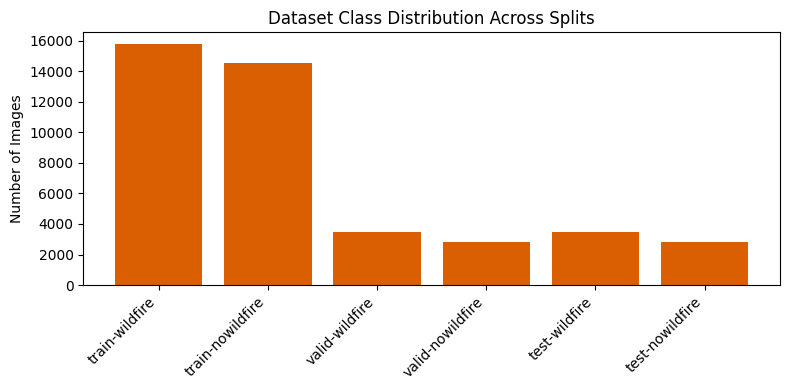

In [ ]:
# 5. Visualize Dataset Distribution
import matplotlib.pyplot as plt
from collections import Counter
import os

def get_class_counts(split):
    split_dir = os.path.join(dst, split)
    counts = Counter()
    if not os.path.exists(split_dir):
        return counts
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            n = sum(len(files) for _, _, files in os.walk(cls_path))
            counts[cls] += n
    return counts

splits = ["train", "valid", "test"]
bar_labels, bar_heights = [], []

for split in splits:
    counts = get_class_counts(split)
    for cls, n in counts.items():
        bar_labels.append(f"{split}-{cls}")
        bar_heights.append(n)

plt.figure(figsize=(8,4))
plt.bar(bar_labels, bar_heights, color=["#d95f02" if "wildfire" in b else "#1b9e77" for b in bar_labels])
plt.ylabel("Number of Images")
plt.title("Dataset Class Distribution Across Splits")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

os.makedirs(os.path.join(base_dir, "results"), exist_ok=True)
plt.savefig(os.path.join(base_dir, "results", "class_distribution.png"), dpi=300)
plt.show()


In [ ]:
# 6. Define Preprocessing & Augmentation Pipelines
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Define image transformations
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

valid_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = datasets.ImageFolder(root=os.path.join(dst, "train"), transform=train_transform)
valid_dataset = datasets.ImageFolder(root=os.path.join(dst, "valid"), transform=valid_test_transform)
test_dataset  = datasets.ImageFolder(root=os.path.join(dst, "test"),  transform=valid_test_transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Summary
class_names = train_dataset.classes
print("Classes:", class_names)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))


Classes: ['nowildfire', 'wildfire']
Train size: 30250
Valid size: 6300
Test size: 6300


In [ ]:
# 7. Compute Class Weights (to handle imbalance)
import numpy as np

labels = np.array([y for _, y in train_dataset.samples])
class_sample_counts = np.bincount(labels).astype(int)

print("Train class counts:", {cls: int(n) for cls, n in zip(class_names, class_sample_counts)})

# Compute normalized inverse-frequency weights
class_weights = 1.0 / (class_sample_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * len(class_weights)
class_weights = class_weights.astype(float)

print("Class weights:", {cls: round(float(w), 4) for cls, w in zip(class_names, class_weights)})

# Save weights for training
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)


Train class counts: {'nowildfire': 14500, 'wildfire': 15750}
Class weights: {'nowildfire': 1.0413, 'wildfire': 0.9587}


In [ ]:
# 8. Baseline CNN Model
import torch
import torch.nn as nn
import torch.nn.functional as F

class WildfireCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(WildfireCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.fc1   = nn.Linear(128 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

model = WildfireCNN(num_classes=2)
print(model)


WildfireCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=8192, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=2, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)


In [ ]:
# 9. Define Loss, Optimizer, and Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# 10. Training Loop (5–10 Epochs)
from tqdm import tqdm
import matplotlib.pyplot as plt

num_epochs = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ----- Validation -----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(valid_loader.dataset)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}: "
          f"Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
          f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


Epoch 1/10: 100%|██████████| 946/946 [02:07<00:00,  7.44it/s]


Epoch 1/10: Train Loss=0.2425, Val Loss=0.1944, Train Acc=0.9070, Val Acc=0.9419


Epoch 2/10: 100%|██████████| 946/946 [02:04<00:00,  7.62it/s]


Epoch 2/10: Train Loss=0.1859, Val Loss=0.1518, Train Acc=0.9298, Val Acc=0.9478


Epoch 3/10: 100%|██████████| 946/946 [02:05<00:00,  7.55it/s]


...

Epoch 8/10: Train Loss=0.1306, Val Loss=0.1058, Train Acc=0.9524, Val Acc=0.9619


Epoch 9/10: 100%|██████████| 946/946 [02:05<00:00,  7.53it/s]


Epoch 9/10: Train Loss=0.1225, Val Loss=0.1092, Train Acc=0.9559, Val Acc=0.9643


Epoch 10/10: 100%|██████████| 946/946 [02:05<00:00,  7.52it/s]


Epoch 10/10: Train Loss=0.1231, Val Loss=0.0998, Train Acc=0.9553, Val Acc=0.9644


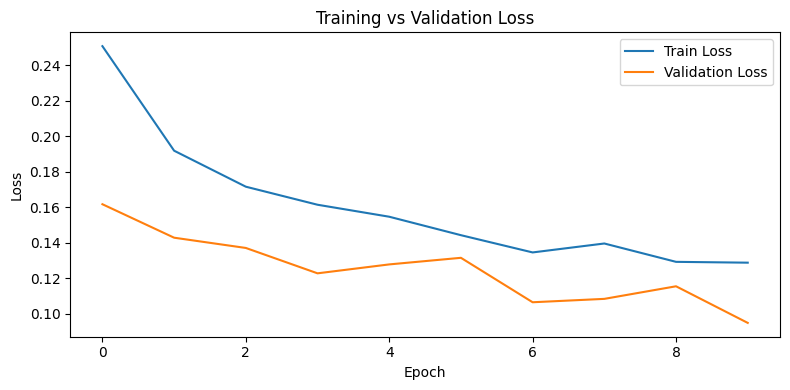

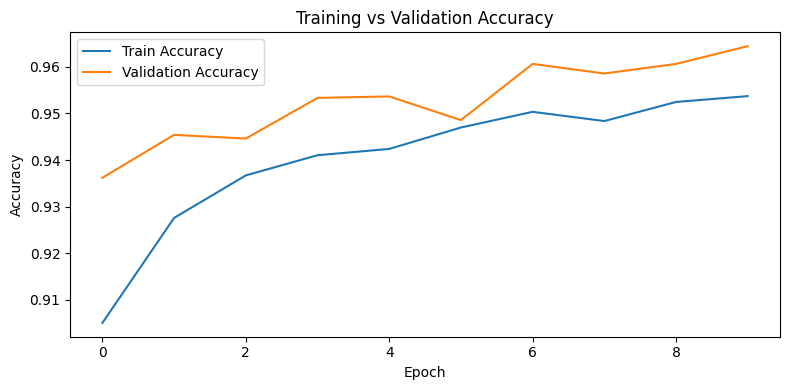

In [ ]:
#11. Plot Loss and Accuracy Curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("wildfire-prediction/results/loss_curve.png", dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("wildfire-prediction/results/accuracy_curve.png", dpi=300)
plt.show()


In [ ]:
#12. Save model
import os
save_path = "wildfire-prediction/models/model_cnn.pt"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

torch.save(model.state_dict(), save_path)

In [ ]:
#13. Reload the Model & prepare the Test Loader
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate model and load saved weights
model = WildfireCNN(num_classes=2).to(device)
model.load_state_dict(torch.load("wildfire-prediction/models/model_cnn.pt", map_location=device))
model.eval()

# Data loader for test set
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [ ]:
#14. make predictions and collect output
import numpy as np
from tqdm import tqdm

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating on Test Set"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())  # probability of "wildfire"


Evaluating on Test Set: 100%|██████████| 197/197 [00:17<00:00, 11.15it/s]


Classification Report:
              precision    recall  f1-score   support

  nowildfire     0.9621    0.9819    0.9719      2820
    wildfire     0.9851    0.9687    0.9768      3480

    accuracy                         0.9746      6300
   macro avg     0.9736    0.9753    0.9744      6300
weighted avg     0.9748    0.9746    0.9746      6300



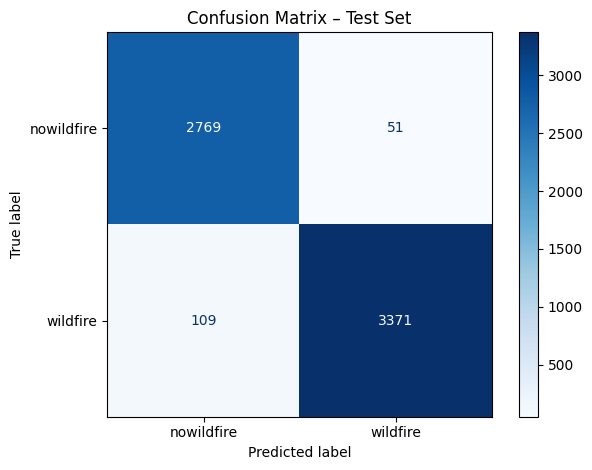

In [ ]:
#15. Classification Report & Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.savefig("wildfire-prediction/results/confusion_matrix.png", dpi=300)
plt.show()


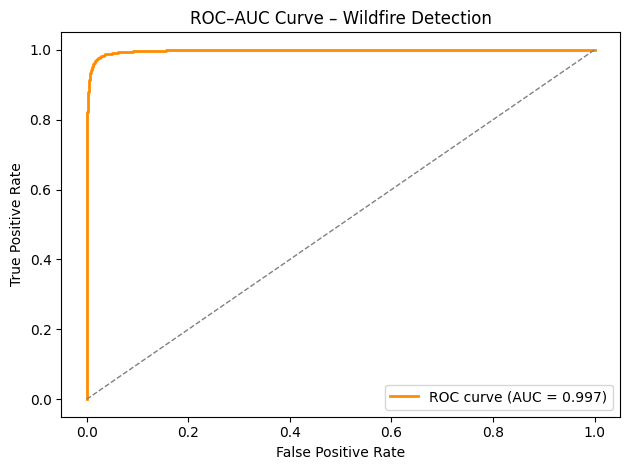

ROC–AUC Score: 0.997


In [ ]:
#16. ROC–AUC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve – Wildfire Detection")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("wildfire-prediction/results/roc_auc_curve.png", dpi=300)
plt.show()

print(f"ROC–AUC Score: {roc_auc:.3f}")


In [ ]:
#17. Load pretrained ResNet50
import torch.nn as nn
from torchvision import models

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace final classification head with 2-class output
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

print("Stage-1 model ready.")


Stage-1 model ready.


In [ ]:
#18. Stage-1 Training Loop
EPOCHS_STAGE1 = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(EPOCHS_STAGE1):
    # --- TRAIN ---
    resnet.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Stage-1 Epoch {epoch+1}/{EPOCHS_STAGE1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    # --- VALIDATION ---
    resnet.eval()
    val_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    val_loss /= len(valid_loader.dataset)
    val_acc = v_correct / v_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Stage-1 Epoch {epoch+1}/{EPOCHS_STAGE1}: "
          f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")


Stage-1 Epoch 1/5: 100%|██████████| 946/946 [02:18<00:00,  6.82it/s]


Stage-1 Epoch 1/5: Train Acc=0.9185, Val Acc=0.9303


Stage-1 Epoch 2/5: 100%|██████████| 946/946 [02:17<00:00,  6.86it/s]


Stage-1 Epoch 2/5: Train Acc=0.9346, Val Acc=0.9343


Stage-1 Epoch 3/5: 100%|██████████| 946/946 [02:17<00:00,  6.86it/s]


Stage-1 Epoch 3/5: Train Acc=0.9384, Val Acc=0.9500


Stage-1 Epoch 4/5: 100%|██████████| 946/946 [02:17<00:00,  6.87it/s]


Stage-1 Epoch 4/5: Train Acc=0.9381, Val Acc=0.9468


Stage-1 Epoch 5/5: 100%|██████████| 946/946 [02:17<00:00,  6.87it/s]


Stage-1 Epoch 5/5: Train Acc=0.9380, Val Acc=0.9479


In [ ]:
import os
os.makedirs("models", exist_ok=True)

torch.save(resnet.state_dict(), "wildfire-prediction/models/resnet50_stage1.pt")
print("Saved: wildfire-prediction/models/resnet50_stage1.pt")


Saved: wildfire-prediction/models/resnet50_stage1.pt


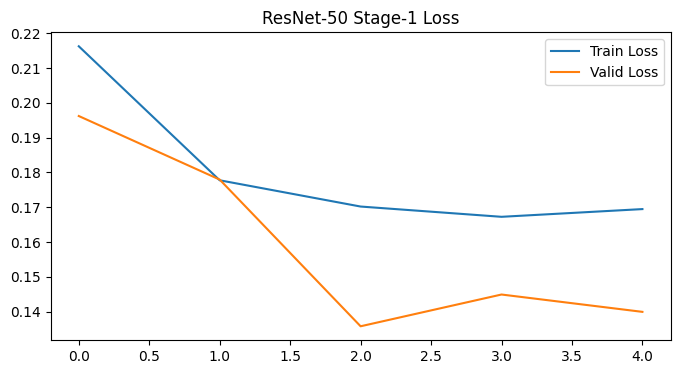

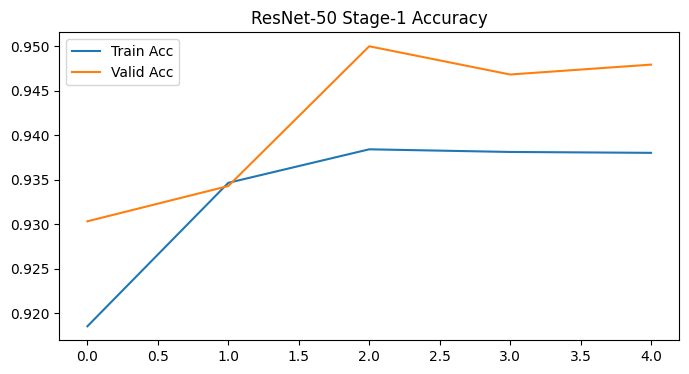

In [ ]:
#19. Plot Stage-1 Curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Valid Loss")
plt.legend()
plt.title("ResNet-50 Stage-1 Loss")
plt.savefig("wildfire-prediction/results/resnet50_stage1_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Valid Acc")
plt.legend()
plt.title("ResNet-50 Stage-1 Accuracy")
plt.savefig("wildfire-prediction/results/resnet50_stage1_accuracy.png", dpi=300)
plt.show()


In [ ]:
#20. Stage-2 Fine-Tuning

# Unfreeze layer3 + layer4 + fc
for name, param in resnet.named_parameters():
    if ("layer3" in name) or ("layer4" in name) or ("fc" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Differential Learning Rates (important)
optimizer = torch.optim.Adam([
    {"params": resnet.layer4.parameters(), "lr": 1e-4},
    {"params": resnet.layer3.parameters(), "lr": 5e-5},
    {"params": resnet.fc.parameters(),      "lr": 1e-4},
], weight_decay=1e-4)

# Add LR scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5
)

EPOCHS_STAGE2 = 8
train_losses2, val_losses2 = [], []
train_accs2, val_accs2 = [], []


In [ ]:
#21. Fine-Tune Training Loop
for epoch in range(EPOCHS_STAGE2):
    resnet.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Stage-2 Epoch {epoch+1}/{EPOCHS_STAGE2}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = resnet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total

    # VALIDATION
    resnet.eval()
    val_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            v_total += labels.size(0)
            v_correct += (predicted == labels).sum().item()

    val_loss /= len(valid_loader.dataset)
    val_acc = v_correct / v_total

    # Store
    train_losses2.append(train_loss)
    val_losses2.append(val_loss)
    train_accs2.append(train_acc)
    val_accs2.append(val_acc)

    # Scheduler update
    scheduler.step(val_loss)

    print(f"Stage-2 Epoch {epoch+1}/{EPOCHS_STAGE2}: "
          f"Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}, LR={optimizer.param_groups[0]['lr']:.6f}")

# Save improved model
torch.save(resnet.state_dict(), "wildfire-prediction/models/resnet50_stage2.pt")
print("Saved Stage-2 model!")


Stage-2 Epoch 1/8: 100%|██████████| 946/946 [02:40<00:00,  5.88it/s]


Stage-2 Epoch 1/8: Train Acc=0.9616, Val Acc=0.9803, LR=0.000100


Stage-2 Epoch 2/8: 100%|██████████| 946/946 [02:42<00:00,  5.82it/s]


Stage-2 Epoch 2/8: Train Acc=0.9799, Val Acc=0.9841, LR=0.000100


Stage-2 Epoch 3/8: 100%|██████████| 946/946 [02:42<00:00,  5.83it/s]


...

Stage-2 Epoch 6/8: Train Acc=0.9950, Val Acc=0.9910, LR=0.000100


Stage-2 Epoch 7/8: 100%|██████████| 946/946 [02:42<00:00,  5.84it/s]


Stage-2 Epoch 7/8: Train Acc=0.9942, Val Acc=0.9892, LR=0.000100


Stage-2 Epoch 8/8: 100%|██████████| 946/946 [02:42<00:00,  5.83it/s]


Stage-2 Epoch 8/8: Train Acc=0.9957, Val Acc=0.9865, LR=0.000100
Saved Stage-2 model!


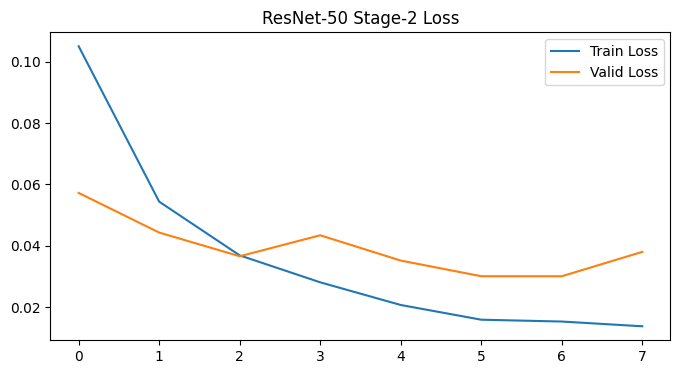

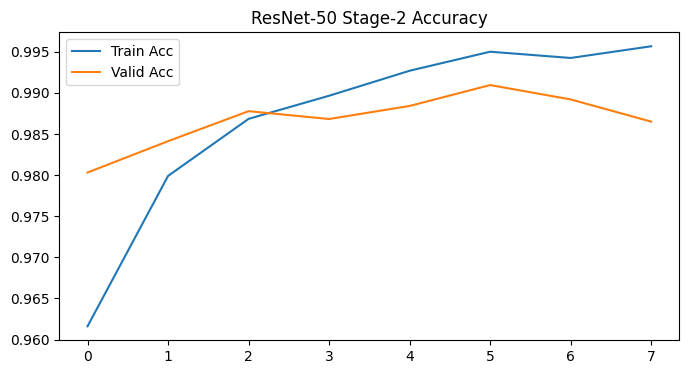

In [ ]:
#22. Plot Stage-2 Curves
plt.figure(figsize=(8,4))
plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Valid Loss")
plt.legend()
plt.title("ResNet-50 Stage-2 Loss")
plt.savefig("wildfire-prediction/results/resnet50_stage2_loss.png", dpi=300)
plt.show()

plt.figure(figsize=(8,4))
plt.plot(train_accs2, label="Train Acc")
plt.plot(val_accs2, label="Valid Acc")
plt.legend()
plt.title("ResNet-50 Stage-2 Accuracy")
plt.savefig("wildfire-prediction/results/resnet50_stage2_accuracy.png", dpi=300)
plt.show()


In [ ]:
#23. Test set evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Load model for test evaluation
model_resnet = models.resnet50(weights=None)
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 2)
model_resnet.load_state_dict(torch.load("wildfire-prediction/models/resnet50_stage2.pt", map_location=device))
model_resnet = model_resnet.to(device)
model_resnet.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="ResNet-50 Test Evaluation"):
        images, labels = images.to(device), labels.to(device)
        outputs = model_resnet(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())


ResNet-50 Test Evaluation: 100%|██████████| 197/197 [00:27<00:00,  7.20it/s]


ResNet-50 Classification Report:
              precision    recall  f1-score   support

  nowildfire     0.9849    0.9961    0.9905      2820
    wildfire     0.9968    0.9876    0.9922      3480

    accuracy                         0.9914      6300
   macro avg     0.9909    0.9919    0.9913      6300
weighted avg     0.9915    0.9914    0.9914      6300



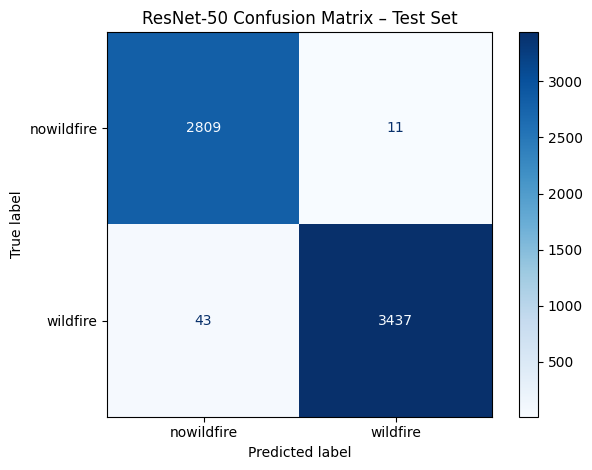

In [ ]:
#24. Classification Report + Confusion Matrix
print("ResNet-50 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("ResNet-50 Confusion Matrix – Test Set")
plt.tight_layout()
plt.savefig("wildfire-prediction/results/resnet50_confusion_matrix.png", dpi=300)
plt.show()


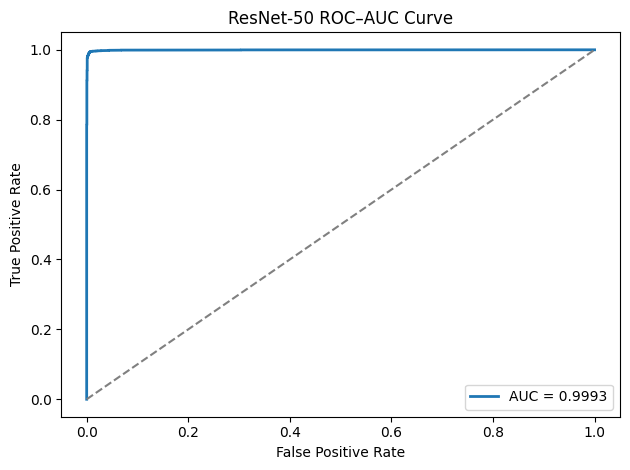

ResNet-50 Test AUC: 0.9993259863862395


In [ ]:
#25.ROC-AUC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet-50 ROC–AUC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("wildfire-prediction/results/resnet50_roc_auc.png", dpi=300)
plt.show()

print("ResNet-50 Test AUC:", roc_auc)
